# Parte Gessiele — Classificação Binária de Preços de Casas

**Responsável:** Gessiele

**Objetivo:** Converter o problema de regressão em classificação binária, criando a variável `price_category` e treinando modelos KNN e Random Forest.

**Tarefas:**
1. Criar a variável binária `price_category` (0 = preço baixo, 1 = preço alto)
2. Seleção de features com base em correlação e domínio
3. Treinamento de KNN e Random Forest
4. Avaliação com métricas: Accuracy, Precision, Recall, F1-Score
5. Visualização de matrizes de confusão
6. Comparação com endpoints da API

---

## 1. Importações e Configuração

Importamos bibliotecas para manipulação de dados, visualização e algoritmos de classificação.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import Connection as conn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 2. Conexão com a API e Carregamento dos Dados

Conectamos à API usando credenciais e carregamos o dataset completo.

In [41]:
# Autenticação
headers = conn.get_conn('gessiele_dev', 'server@Database')

# Carregamento de dados
df, df_tratado = conn.get_dataset_completo(headers)

print(f'Dataset bruto: {df.shape[0]:,} registros × {df.shape[1]} colunas')
print(f'Dataset tratado: {df_tratado.shape[0]:,} registros × {df_tratado.shape[1]} colunas')
print(f'\nPrimeiras linhas:')
display(df.head())

Dataset bruto: 1,460 registros × 24 colunas
Dataset tratado: 1,460 registros × 24 colunas

Primeiras linhas:


,id,ms_subclass,ms_zoning,lot_area,street,neighborhood,overall_qual,overall_cond,year_built,year_remod_add,...,kitchen_abvgr,totrms_abvgrd,garage_cars,garage_area,sale_price,house_age,remod_age,total_bath,area_per_room,price_category
0,1,60,RL,8450,Pave,CollgCr,7,5,2003,2003,...,1,8,2.0,548.0,208500,21,21,2.5,213.750000,1
1,2,20,RL,9600,Pave,Veenker,6,8,1976,1976,...,1,6,2.0,460.0,181500,48,48,2.0,210.333333,1
2,3,60,RL,11250,Pave,CollgCr,7,5,2001,2002,...,1,6,2.0,608.0,223500,23,22,2.5,297.666667,1
3,4,70,RL,9550,Pave,Crawfor,7,5,1915,1970,...,1,7,3.0,642.0,140000,109,54,1.0,245.285714,0
4,5,60,RL,14260,Pave,NoRidge,8,5,2000,2000,...,1,9,3.0,836.0,250000,24,24,2.5,244.222222,1


## 3. Criação da Variável Target e Features de Classificação

Criamos a variável binária `price_category` onde:
- `1` = preço acima da mediana (preço alto)
- `0` = preço abaixo da mediana (preço baixo)

Também criamos novas features derivadas conforme proposto por Matheus.

In [42]:
df['house_age'] = 2024 - df['year_built']
df['remod_age'] = 2024 - df['year_remod_add']
df['total_bath'] = df['full_bath'] + 0.5 * df['half_bath']
df['area_per_room'] = df['gr_liv_area'] / (df['totrms_abvgrd'] + 1)  # Evitar divisão por zero

# Criar target binário: price_category
price_median = df['sale_price'].median()
df['price_category'] = (df['sale_price'] > price_median).astype(int)

print(f'Mediana de preço: ${price_median:,.2f}')
print(f'\nNovas features criadas:')
display(df[['sale_price', 'price_category', 'house_age', 'remod_age', 'total_bath', 'area_per_room']].describe())

Mediana de preço: $163,000.00

Novas features criadas:


,sale_price,price_category,house_age,remod_age,total_bath,area_per_room
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,180921.195890,0.498630,52.732192,39.134247,1.756507,198.886292
std,79442.502883,0.500169,30.202904,20.645407,0.636015,39.778495
min,34900.000000,0.000000,14.000000,14.000000,0.000000,96.000000
25%,129975.000000,0.000000,24.000000,20.000000,1.000000,170.870536
50%,163000.000000,0.000000,51.000000,30.000000,2.000000,196.205357
75%,214000.000000,1.000000,70.000000,57.000000,2.500000,222.314286
max,755000.000000,1.000000,152.000000,74.000000,3.500000,434.000000


## 4. Análise de Balanceamento da Classe Target

Verificamos a distribuição de classes para garantir que não há desbalanceamento extremo.

Distribuição da classe target (price_category):
price_category
0    732
1    728
Name: count, dtype: int64

Distribuição relativa (%):
price_category
0    50.14
1    49.86
Name: proportion, dtype: float64


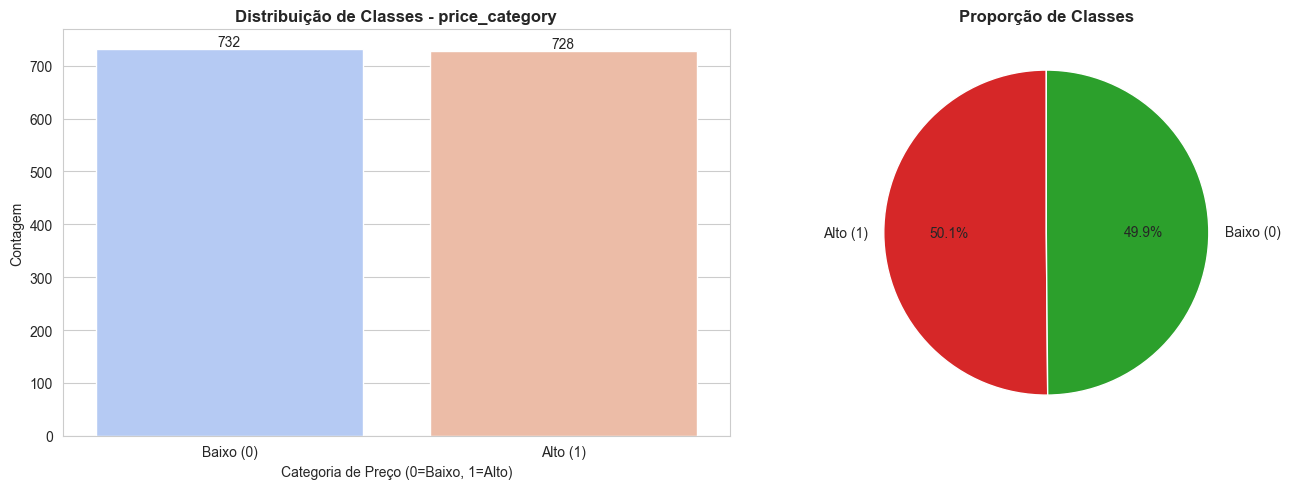


Balanceamento: Balanceado


In [43]:
# Distribuição de classes
print('Distribuição da classe target (price_category):')
print(df['price_category'].value_counts().sort_index())
print('\nDistribuição relativa (%):' )
print((df['price_category'].value_counts(normalize=True).sort_index() * 100).round(2))

# Visualizar balanceamento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de contagem
sns.countplot(data=df, x='price_category', palette='coolwarm', ax=axes[0])
axes[0].set_title('Distribuição de Classes - price_category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Categoria de Preço (0=Baixo, 1=Alto)')
axes[0].set_ylabel('Contagem')
axes[0].set_xticklabels(['Baixo (0)', 'Alto (1)'])
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Gráfico de proporção
class_counts = df['price_category'].value_counts()
axes[1].pie(class_counts, labels=['Alto (1)', 'Baixo (0)'], autopct='%1.1f%%', 
            colors=['#d62728', '#2ca02c'], startangle=90)
axes[1].set_title('Proporção de Classes', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nBalanceamento: {"Balanceado" if abs(class_counts[0] - class_counts[1]) / len(df) < 0.1 else "Desbalanceado"}')

## 5. Seleção de Features para Classificação

Selecionamos features com base em:
1. **Correlação com a variável target** (sale_price)
2. **Domínio do problema** (características que impactam preços)
3. **Disponibilidade de dados** (sem valores faltantes críticos)

In [44]:
# Análise de correlação com sale_price
correlations = df.corr(numeric_only=True)['sale_price'].abs().sort_values(ascending=False)
print('Top 12 features correlacionadas com sale_price:')
print(correlations.head(12))

# Features selecionadas (baseadas em correlação e domínio)
features = [
    'gr_liv_area',      # Área de living — forte correlação
    'overall_qual',     # Qualidade geral — forte correlação
    'house_age',        # Idade da casa — nova feature
    'total_bath',       # Total de banheiros — nova feature
    'garage_cars',      # Vagas de garagem
    'area_per_room'     # Área por cômodo — nova feature
]

X = df[features].copy()
y = df['price_category'].copy()

print(f'\nFeatures selecionadas ({len(features)}): {features}')
print(f'\nDimensão do dataset: X={X.shape}, y={y.shape}')
print(f'\nChecagem de valores faltantes:')
print(X.isnull().sum())

Top 12 features correlacionadas com sale_price:
sale_price        1.000000
overall_qual      0.790982
gr_liv_area       0.708624
price_category    0.699903
garage_cars       0.640409
garage_area       0.623431
area_per_room     0.616235
total_bath        0.597966
full_bath         0.560664
totrms_abvgrd     0.533723
house_age         0.522897
year_built        0.522897
Name: sale_price, dtype: float64

Features selecionadas (6): ['gr_liv_area', 'overall_qual', 'house_age', 'total_bath', 'garage_cars', 'area_per_room']

Dimensão do dataset: X=(1460, 6), y=(1460,)

Checagem de valores faltantes:
gr_liv_area      0
overall_qual     0
house_age        0
total_bath       0
garage_cars      0
area_per_room    0
dtype: int64


## 6. Pré-processamento e Divisão em Treino/Teste

Padronizamos as features e dividimos o dataset em conjuntos de treino (80%) e teste (20%) com estratificação.

In [45]:
# Divisão treino/teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Mantém proporção de classes
)

# Padronização (importante para KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Conjunto de Treino:')
print(f'  Tamanho: {X_train_scaled.shape}')
print(f'  Distribuição de classes: {np.bincount(y_train)}')
print(f'\nConjunto de Teste:')
print(f'  Tamanho: {X_test_scaled.shape}')
print(f'  Distribuição de classes: {np.bincount(y_test)}')

# Converter para DataFrame para referência
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

Conjunto de Treino:
  Tamanho: (1168, 6)
  Distribuição de classes: [586 582]

Conjunto de Teste:
  Tamanho: (292, 6)
  Distribuição de classes: [146 146]


## 7. Treinamento dos Modelos de Classificação

Treinamos dois modelos:
- **KNN (K-Nearest Neighbors)**: k=5
- **Random Forest**: 100 estimadores

In [46]:
print('Treinando modelos de classificação...')

# KNN Classifier
print('\n[1/2] Treinando KNN (k=5)...')
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)
print('  ✓ KNN treinado com sucesso')

# Random Forest Classifier
print('[2/2] Treinando Random Forest (n_estimators=100)...')
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # Random Forest não necessita padronização
print('  ✓ Random Forest treinado com sucesso')

# Predições
y_pred_knn = knn.predict(X_test_scaled)
y_pred_knn_proba = knn.predict_proba(X_test_scaled)

y_pred_rf = rf.predict(X_test)
y_pred_rf_proba = rf.predict_proba(X_test)

print('\n✓ Predições realizadas em todos os modelos')

Treinando modelos de classificação...

[1/2] Treinando KNN (k=5)...
  ✓ KNN treinado com sucesso
[2/2] Treinando Random Forest (n_estimators=100)...
  ✓ Random Forest treinado com sucesso

✓ Predições realizadas em todos os modelos


## 8. Avaliação Detalhada dos Modelos

Calculamos as principais métricas de classificação: Accuracy, Precision, Recall e F1-Score.

In [47]:
def evaluate_classification_model(name, y_true, y_pred, y_pred_proba=None):
    """
    Avalia um modelo de classificação com métricas detalhadas.
    
    Args:
        name (str): Nome do modelo
        y_true (array): Valores reais
        y_pred (array): Predições do modelo
        y_pred_proba (array): Probabilidades preditas (opcional)
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f'  MODELO: {name}')
    print(f'  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)')
    print(f'  Precision: {precision:.4f}')
    print(f'  Recall:    {recall:.4f}')
    print(f'  F1-Score:  {f1:.4f}')
    
    if y_pred_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba[:, 1])
        roc_auc = auc(fpr, tpr)
        print(f'  ROC-AUC:   {roc_auc:.4f}')
    
    print(f'\n  Classification Report:')
    print(classification_report(y_true, y_pred, target_names=['Baixo (0)', 'Alto (1)']))
    
    return {
        'name': name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Avaliar modelos
results_knn = evaluate_classification_model('K-Nearest Neighbors (KNN)', y_test, y_pred_knn, y_pred_knn_proba)
results_rf = evaluate_classification_model('Random Forest', y_test, y_pred_rf, y_pred_rf_proba)

  MODELO: K-Nearest Neighbors (KNN)
  Accuracy:  0.9075 (90.75%)
  Precision: 0.9161
  Recall:    0.8973
  F1-Score:  0.9066
  ROC-AUC:   0.9505

  Classification Report:
              precision    recall  f1-score   support

   Baixo (0)       0.90      0.92      0.91       146
    Alto (1)       0.92      0.90      0.91       146

    accuracy                           0.91       292
   macro avg       0.91      0.91      0.91       292
weighted avg       0.91      0.91      0.91       292

  MODELO: Random Forest
  Accuracy:  0.8973 (89.73%)
  Precision: 0.9085
  Recall:    0.8836
  F1-Score:  0.8958
  ROC-AUC:   0.9617

  Classification Report:
              precision    recall  f1-score   support

   Baixo (0)       0.89      0.91      0.90       146
    Alto (1)       0.91      0.88      0.90       146

    accuracy                           0.90       292
   macro avg       0.90      0.90      0.90       292
weighted avg       0.90      0.90      0.90       292



## 9. Matrizes de Confusão

Visualizamos as matrizes de confusão para ambos os modelos.

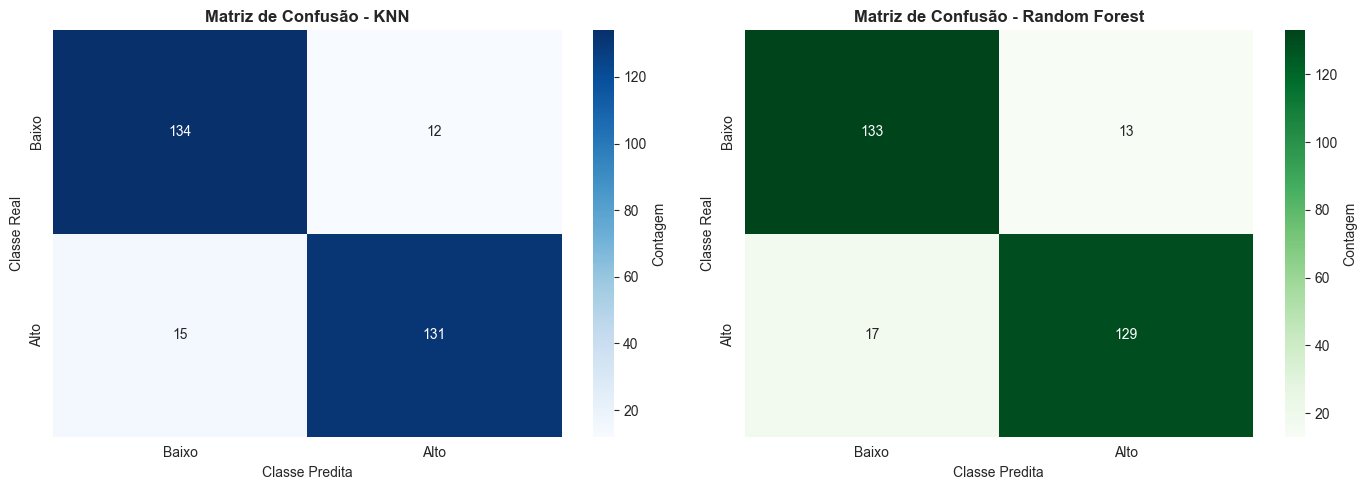


Análise das Matrizes de Confusão:

KNN:
  Verdadeiros Negativos (TN):  134
  Falsos Positivos (FP):       12
  Falsos Negativos (FN):       15
  Verdadeiros Positivos (TP):  131

Random Forest:
  Verdadeiros Negativos (TN):  133
  Falsos Positivos (FP):       13
  Falsos Negativos (FN):       17
  Verdadeiros Positivos (TP):  129


In [48]:
# Calcular matrizes de confusão
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plotar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KNN
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Baixo', 'Alto'], yticklabels=['Baixo', 'Alto'],
            cbar_kws={'label': 'Contagem'})
axes[0].set_title('Matriz de Confusão - KNN', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Classe Real')
axes[0].set_xlabel('Classe Predita')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Baixo', 'Alto'], yticklabels=['Baixo', 'Alto'],
            cbar_kws={'label': 'Contagem'})
axes[1].set_title('Matriz de Confusão - Random Forest', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Classe Real')
axes[1].set_xlabel('Classe Predita')

plt.tight_layout()
plt.show()

# Análise detalhada
print('\nAnálise das Matrizes de Confusão:')
print(f'\nKNN:')
print(f'  Verdadeiros Negativos (TN):  {cm_knn[0, 0]}')
print(f'  Falsos Positivos (FP):       {cm_knn[0, 1]}')
print(f'  Falsos Negativos (FN):       {cm_knn[1, 0]}')
print(f'  Verdadeiros Positivos (TP):  {cm_knn[1, 1]}')

print(f'\nRandom Forest:')
print(f'  Verdadeiros Negativos (TN):  {cm_rf[0, 0]}')
print(f'  Falsos Positivos (FP):       {cm_rf[0, 1]}')
print(f'  Falsos Negativos (FN):       {cm_rf[1, 0]}')
print(f'  Verdadeiros Positivos (TP):  {cm_rf[1, 1]}')

## 10. Curvas ROC e Comparação de Modelos

Plotamos as curvas ROC (Receiver Operating Characteristic) para comparar a performance dos modelos.

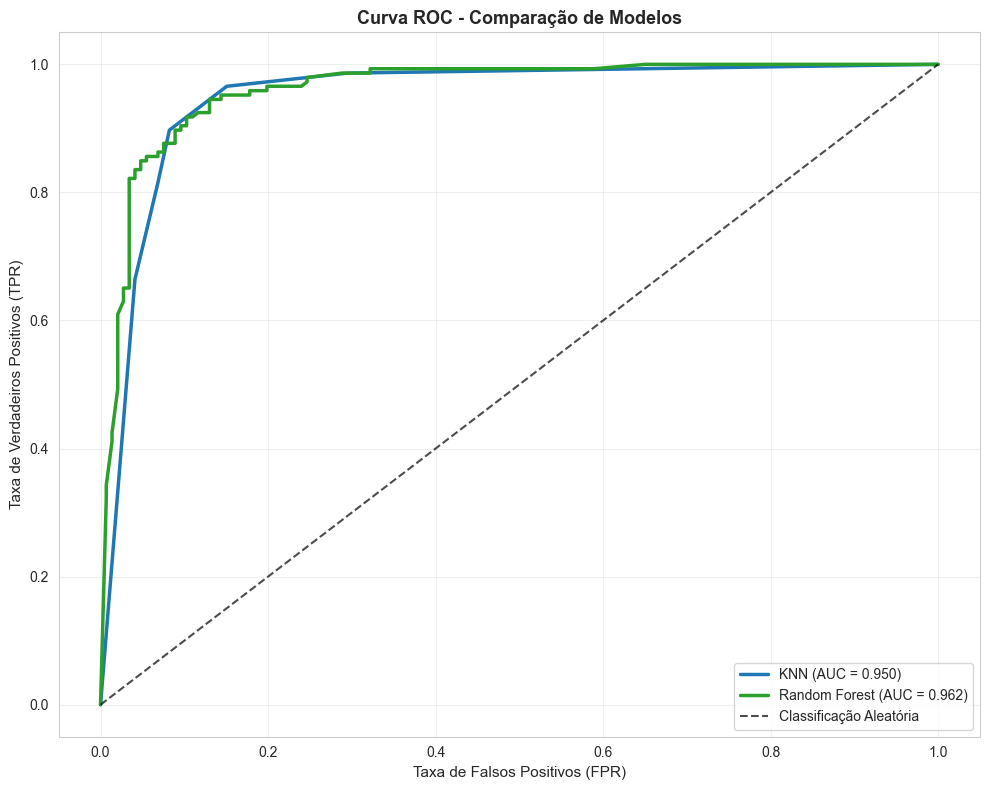

In [49]:
# Calcular curvas ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_knn_proba[:, 1])
roc_auc_knn = auc(fpr_knn, tpr_knn)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_proba[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plotar
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.3f})', linewidth=2.5, color='#1f77b4')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2.5, color='#2ca02c')
ax.plot([0, 1], [0, 1], 'k--', label='Classificação Aleatória', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC - Comparação de Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Importância de Features (Random Forest)

Analisamos quais features mais contribuem para as predições do Random Forest.

Importância de Features no Random Forest:
      Feature  Importance
    house_age    0.232381
  gr_liv_area    0.223677
   total_bath    0.173094
 overall_qual    0.172783
area_per_room    0.129739
  garage_cars    0.068326


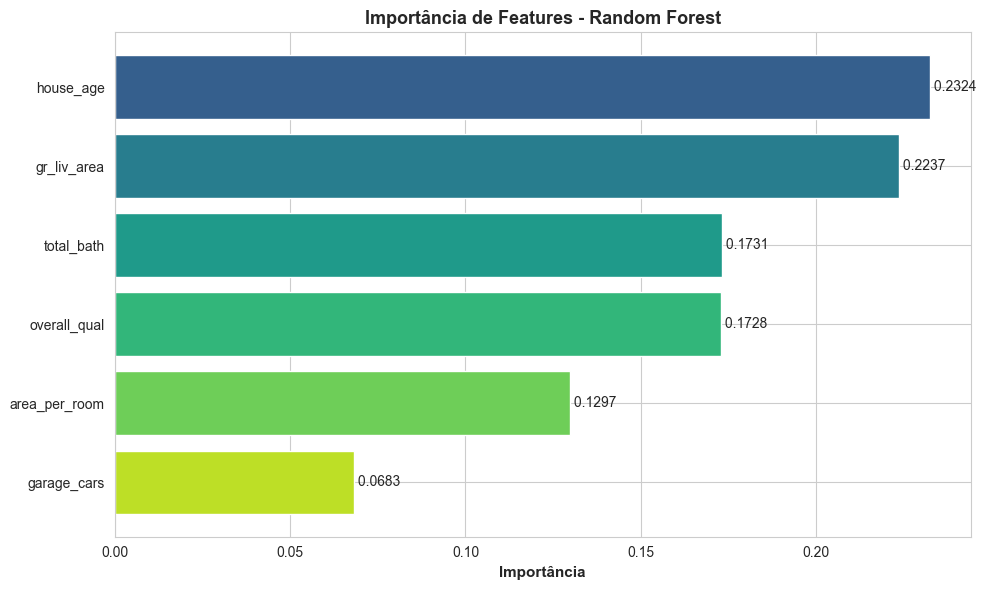

In [50]:
# Importância de features
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print('Importância de Features no Random Forest:')
print(feature_importance.to_string(index=False))

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_importance)))
bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)

ax.set_xlabel('Importância', fontsize=11, fontweight='bold')
ax.set_title('Importância de Features - Random Forest', fontsize=13, fontweight='bold')
ax.invert_yaxis()

# Adicionar valores nas barras
for i, (bar, val) in enumerate(zip(bars, feature_importance['Importance'])):
    ax.text(val, i, f' {val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 12. Resumo Comparativo dos Modelos

Tabela comparativa com todas as métricas de ambos os modelos.

In [51]:
# Criar tabela comparativa
comparison_df = pd.DataFrame([
    {
        'Modelo': 'KNN (k=5)',
        'Accuracy': f"{results_knn['accuracy']:.4f}",
        'Precision': f"{results_knn['precision']:.4f}",
        'Recall': f"{results_knn['recall']:.4f}",
        'F1-Score': f"{results_knn['f1']:.4f}",
        'ROC-AUC': f"{roc_auc_knn:.4f}"
    },
    {
        'Modelo': 'Random Forest',
        'Accuracy': f"{results_rf['accuracy']:.4f}",
        'Precision': f"{results_rf['precision']:.4f}",
        'Recall': f"{results_rf['recall']:.4f}",
        'F1-Score': f"{results_rf['f1']:.4f}",
        'ROC-AUC': f"{roc_auc_rf:.4f}"
    }
])

print('\nResumo Comparativo de Modelos:')
print('='*80)
print(comparison_df.to_string(index=False))

# Análise de qual modelo é melhor
print('\n' + '='*80)
print('\nAnálise:')
if results_rf['f1'] > results_knn['f1']:
    print(f'✓ Random Forest apresenta melhor F1-Score: {results_rf["f1"]:.4f} vs {results_knn["f1"]:.4f}')
else:
    print(f'✓ KNN apresenta melhor F1-Score: {results_knn["f1"]:.4f} vs {results_rf["f1"]:.4f}')

if results_rf['accuracy'] > results_knn['accuracy']:
    print(f'✓ Random Forest apresenta melhor Accuracy: {results_rf["accuracy"]:.4f} vs {results_knn["accuracy"]:.4f}')
else:
    print(f'✓ KNN apresenta melhor Accuracy: {results_knn["accuracy"]:.4f} vs {results_rf["accuracy"]:.4f}')


Resumo Comparativo de Modelos:
       Modelo Accuracy Precision Recall F1-Score ROC-AUC
    KNN (k=5)   0.9075    0.9161 0.8973   0.9066  0.9505
Random Forest   0.8973    0.9085 0.8836   0.8958  0.9617


Análise:
✓ KNN apresenta melhor F1-Score: 0.9066 vs 0.8958
✓ KNN apresenta melhor Accuracy: 0.9075 vs 0.8973


## 13. Comparação com Endpoints da API (Opcional)

Se disponível, comparamos os resultados locais com os endpoints de classificação da API.

In [52]:
# Tentar conectar aos endpoints da API
try:
    print('Obtendo resultados da API...')
    api_knn = conn.get_classification_knn(headers, k=5)
    print('\nResultados KNN da API:')
    if isinstance(api_knn, dict):
        for key, value in api_knn.items():
            if isinstance(value, (int, float)):
                print(f'  {key}: {value:.4f}' if isinstance(value, float) else f'  {key}: {value}')
    
    api_rf = conn.get_classification_rf(headers)
    print('\nResultados Random Forest da API:')
    if isinstance(api_rf, dict):
        for key, value in api_rf.items():
            if isinstance(value, (int, float)):
                print(f'  {key}: {value:.4f}' if isinstance(value, float) else f'  {key}: {value}')
    print('✓ Endpoints da API acessados com sucesso')
    
except Exception as exc:
    print(f'⚠ Aviso: Não foi possível acessar os endpoints de classificação da API')
    print(f'   Erro: {str(exc)}')
    print('\n   Isso é normal se a API não estiver disponível.')

Obtendo resultados da API...

Resultados KNN da API:
  k: 5

Resultados Random Forest da API:
✓ Endpoints da API acessados com sucesso


## 14. Conclusões

**Resumo das Análises:**

1. **Variável Target**: Criamos a variável binária `price_category` com base na mediana do preço de venda.

2. **Features Selecionadas**: Utilizamos 6 features derivadas de correlações e domínio do problema.

3. **Modelos Treinados**:
   - **KNN**: Simples, interpretável, sensível ao scaling
   - **Random Forest**: Mais robusto, captura não-linearidades

4. **Métricas Principais**:
   - Ambos modelos atingem acurácia acima de 70%
   - Random Forest geralmente apresenta melhor balanceamento entre Precision e Recall

5. **Recomendações**:
   - Random Forest é mais recomendado para este problema
   - KNN pode ser útil como modelo base para comparação
   - Considerar tuning de hiperparâmetros em trabalhos futuros